In [35]:
!pip -q install -U "transformers>=4.51.0" accelerate sentencepiece huggingface_hub pandas matplotlib

In [36]:
import os, re, json, gc, math, random, torch
import pandas as pd
import matplotlib.pyplot as plt

from transformers import AutoTokenizer, AutoModelForCausalLM
from huggingface_hub import hf_hub_download

random.seed(1)

SET = {
    "model_name": "Qwen/Qwen3-8B",
    "run_set": "s",                 # "oracle", "s", "m"
    "max_cases": 100,                # start small
    "hard_only": True,

    # context / retrieval
    "baseline_budget": 8000,
    "memory_budget": 8000,
    "recent_budget": 10000,
    "top_k_sessions": 6,

    # generation
    "max_new_tokens_answer": 240,
    "max_new_tokens_extract": 2200,
    "do_sample": False,
    "temperature": None,
    "top_p": None,
    "top_k": None,

    # dataset / output
    "save_dir": "runs_simple",
}

PRESETS = {
    "fast_debug": {
        "run_set": "s",
        "max_cases": 5,
        "baseline_budget": 5000,
        "memory_budget": 5000,
        "recent_budget": 800,
        "top_k_sessions": 4,
        "max_new_tokens_answer": 16,
        "max_new_tokens_extract": 160,
    },
    "balanced": {
        "run_set": "s",
        "max_cases": 25,
        "baseline_budget": 8000,
        "memory_budget": 8000,
        "recent_budget": 1000,
        "top_k_sessions": 6,
        "max_new_tokens_answer": 24,
        "max_new_tokens_extract": 220,
    },
    "longer_context": {
        "run_set": "s",
        "max_cases": 250,
        "baseline_budget": 12000,
        "memory_budget": 12000,
        "recent_budget": 1500,
        "top_k_sessions": 8,
        "max_new_tokens_answer": 24,
        "max_new_tokens_extract": 280,
    }
}

def use_preset(name):
    SET.update(PRESETS[name])
    print("using preset:", name)
    print(json.dumps(SET, indent=2))

os.makedirs(SET["save_dir"], exist_ok=True)
use_preset("longer_context")

using preset: longer_context
{
  "model_name": "Qwen/Qwen3-8B",
  "run_set": "s",
  "max_cases": 250,
  "hard_only": true,
  "baseline_budget": 12000,
  "memory_budget": 12000,
  "recent_budget": 1500,
  "top_k_sessions": 8,
  "max_new_tokens_answer": 24,
  "max_new_tokens_extract": 280,
  "do_sample": false,
  "temperature": null,
  "top_p": null,
  "top_k": null,
  "save_dir": "runs_simple"
}


In [37]:
tok = AutoTokenizer.from_pretrained(SET["model_name"], trust_remote_code=True)
if tok.pad_token is None:
    tok.pad_token = tok.eos_token

model = AutoModelForCausalLM.from_pretrained(
    SET["model_name"],
    torch_dtype="auto",
    device_map="auto",
    trust_remote_code=True
)

model.generation_config.do_sample = False
model.generation_config.temperature = None
model.generation_config.top_p = None
model.generation_config.top_k = None

eos_ids = []
for x in [tok.eos_token_id]:
    if x is not None and x not in eos_ids:
        eos_ids.append(x)

print("loaded:", SET["model_name"])
print("device:", next(model.parameters()).device)
print("eos ids:", eos_ids)

Loading weights:   0%|          | 0/399 [00:00<?, ?it/s]

loaded: Qwen/Qwen3-8B
device: cuda:0
eos ids: [151645]


In [38]:
def llm(msg, system="", max_new_tokens=32):
    msgs = []
    if system:
        msgs.append({"role": "system", "content": system})
    msgs.append({"role": "user", "content": msg})

    txt = tok.apply_chat_template(
        msgs,
        tokenize=False,
        add_generation_prompt=True,
        enable_thinking=False
    )

    x = tok(txt, return_tensors="pt", truncation=True).to(model.device)

    kw = dict(
        **x,
        max_new_tokens=max_new_tokens,
        do_sample=SET["do_sample"],
        eos_token_id=eos_ids if eos_ids else tok.eos_token_id,
        pad_token_id=tok.eos_token_id,
    )

    if SET["do_sample"]:
        if SET["temperature"] is not None:
            kw["temperature"] = SET["temperature"]
        if SET["top_p"] is not None:
            kw["top_p"] = SET["top_p"]
        if SET["top_k"] is not None:
            kw["top_k"] = SET["top_k"]

    with torch.inference_mode():
        y = model.generate(**kw)

    z = y[0][x["input_ids"].shape[1]:]
    out = tok.decode(z, skip_special_tokens=True).strip()

    del x, y, z
    gc.collect()
    if torch.cuda.is_available():
        torch.cuda.empty_cache()

    return out

def get_answer_text(txt):
    m = re.search(r"<ans>(.*?)</ans>", txt, flags=re.S | re.I)
    if m:
        return re.sub(r"\s+", " ", m.group(1)).strip()
    txt = re.sub(r"^answer\s*[:\-]\s*", "", txt.strip(), flags=re.I)
    txt = txt.split("\n")[0].strip()
    return txt[:200]

def get_json_list(txt):
    txt = txt.strip()
    txt = re.sub(r"^```json\s*", "", txt)
    txt = re.sub(r"^```\s*", "", txt)
    txt = re.sub(r"\s*```$", "", txt)

    m = re.search(r"\[[\s\S]*\]", txt)
    if not m:
        return []

    try:
        obj = json.loads(m.group(0))
        return obj if isinstance(obj, list) else []
    except:
        return []

print(get_answer_text("<ans>Austin</ans>"))
print(get_json_list('[{"entity":"Jacob","slot":"city","value":"Austin"}]'))

Austin
[{'entity': 'Jacob', 'slot': 'city', 'value': 'Austin'}]


In [39]:
repo = "xiaowu0162/longmemeval-cleaned"
files = {
    "oracle": "longmemeval_oracle.json",
    "s": "longmemeval_s_cleaned.json",
    "m": "longmemeval_m_cleaned.json"
}

fp = hf_hub_download(repo_id=repo, filename=files[SET["run_set"]], repo_type="dataset")

with open(fp, "r") as f:
    ds = json.load(f)

print("loaded:", len(ds))

loaded: 500


In [40]:
from collections import Counter

def is_hard(item):
    qt = item.get("question_type", "").lower()
    qid = item.get("question_id", "").lower()
    return (
        ("multi" in qt) or
        ("temporal" in qt) or
        ("knowledge" in qt) or
        ("update" in qt) or
        ("abst" in qt) or
        ("false" in qt) or
        qid.endswith("_abs")
    )

print("before:", len(ds))
print(Counter(x.get("question_type", "") for x in ds))

if SET["hard_only"]:
    ds = [x for x in ds if is_hard(x)]

if SET["max_cases"] is not None:
    ds = ds[:SET["max_cases"]]

print("after:", len(ds))
print(Counter(x.get("question_type", "") for x in ds))

before: 500
Counter({'multi-session': 133, 'temporal-reasoning': 133, 'knowledge-update': 78, 'single-session-user': 70, 'single-session-assistant': 56, 'single-session-preference': 30})
after: 250
Counter({'multi-session': 133, 'temporal-reasoning': 111, 'single-session-user': 6})


In [41]:
def norm(x):
    if x is None:
        return ""
    if isinstance(x, list):
        x = " ".join(str(v) for v in x)
    else:
        x = str(x)
    x = x.lower().strip()
    x = re.sub(r"[^a-z0-9\s\-]", "", x)
    x = re.sub(r"\s+", " ", x)
    return x

def toks(x):
    xs = norm(x).split()
    stop = {
        "the","a","an","and","or","but","if","then","to","of","in","on","at","for",
        "from","with","by","is","are","was","were","be","been","being","it","this",
        "that","these","those","what","when","where","who","whom","which","why","how",
        "does","did","do","has","have","had","as","about","into","over","after","before",
        "up","down","out","off","again","further","than","once","now","current","currently"
    }
    return {w for w in xs if len(w) > 2 and w not in stop}

def n_tok(txt):
    return len(tok(txt, add_special_tokens=False)["input_ids"])

def clip_to_budget(txt, budget):
    ids = tok(txt, add_special_tokens=False)["input_ids"][:budget]
    return tok.decode(ids, skip_special_tokens=True)

def session_text(sess, dt=None, sid=None):
    head = []
    if sid is not None:
        head.append(f"Session {sid}")
    if dt is not None:
        head.append(f"Date {dt}")
    top = " | ".join(head)

    body = []
    for t in sess:
        role = t.get("role", "")
        content = t.get("content", "")
        body.append(f"{role}: {content}")

    body = "\n".join(body)
    return (top + "\n" if top else "") + body

In [42]:
def rank_sessions(item):
    qtok = toks(item["question"])
    out = []

    for i, sess in enumerate(item["haystack_sessions"]):
        stxt = session_text(
            sess,
            item["haystack_dates"][i],
            item["haystack_session_ids"][i]
        )
        score = len(qtok & toks(stxt))
        out.append((score, i, stxt, n_tok(stxt)))

    out.sort(reverse=True)
    return out

def selected_history(item, budget_key="baseline_budget"):
    budget = SET[budget_key]
    rows = rank_sessions(item)

    used = 0
    keep = []

    for score, i, stxt, nt in rows:
        if len(keep) >= SET["top_k_sessions"]:
            break
        if nt > budget:
            continue
        if used + nt > budget:
            continue
        keep.append((i, stxt))
        used += nt

    keep.sort(key=lambda x: x[0])
    return "\n\n".join(x[1] for x in keep)

def recent_history(item):
    budget = SET["recent_budget"]
    used = 0
    out = []

    for i in range(len(item["haystack_sessions"]) - 1, -1, -1):
        stxt = session_text(
            item["haystack_sessions"][i],
            item["haystack_dates"][i],
            item["haystack_session_ids"][i]
        )
        nt = n_tok(stxt)
        if used + nt > budget:
            break
        out.append(stxt)
        used += nt

    out.reverse()
    return "\n\n".join(out)

In [43]:
BASE_SYS = "You answer questions from conversation evidence only. Be short, literal, and do not explain."
MEM_SYS = "You answer questions from extracted frame-style memory. Use only supported facts. Be short and literal."
FACT_SYS = "Extract concise frame-style facts from conversation history."

def answer_base(item):
    hist = selected_history(item, "baseline_budget")
    prompt = f'''
Return the final answer inside <ans>...</ans>.

Rules:
- Use only the selected history.
- If a fact changed, prefer the newest valid fact.
- If unsupported, answer <ans>unknown</ans>.
- Keep the answer short.

Selected history:
{hist}

Question: {item["question"]}
'''.strip()

    out = llm(prompt, system=BASE_SYS, max_new_tokens=SET["max_new_tokens_answer"])
    return get_answer_text(out)

def extract_memory_frames(item):
    hist = selected_history(item, "memory_budget")
    recent = recent_history(item)

    prompt = f'''
Extract a JSON list of frame-style facts from the conversation.

Return only JSON.
Each item must look like:
{{"entity":"...", "slot":"...", "value":"...", "time":"...", "status":"active"}}

Rules:
- Keep only facts useful for answering future questions.
- Focus on preferences, identity, plans, deadlines, locations, relationships, constraints, and updates.
- If a fact changed, include the newest fact and mark older or superseded ones as "outdated" only if explicitly present.
- Keep values concise.
- At most 20 items.

Selected history:
{hist}

Recent context:
{recent}

JSON:
'''.strip()

    raw = llm(prompt, system=FACT_SYS, max_new_tokens=SET["max_new_tokens_extract"])
    frames = get_json_list(raw)

    clean = []
    for d in frames:
        if not isinstance(d, dict):
            continue
        entity = str(d.get("entity", "")).strip()
        slot = str(d.get("slot", "")).strip()
        value = str(d.get("value", "")).strip()
        time = str(d.get("time", "")).strip()
        status = str(d.get("status", "active")).strip().lower() or "active"
        if entity and slot and value:
            clean.append({
                "entity": entity,
                "slot": slot,
                "value": value,
                "time": time,
                "status": status
            })
    return clean[:20]

def frames_text(frames):
    if not frames:
        return "[]"
    return json.dumps(frames, ensure_ascii=False, indent=2)

def answer_mem(item):
    frames = extract_memory_frames(item)
    prompt = f'''
Return the final answer inside <ans>...</ans>.

Rules:
- Use the memory frames first.
- Prefer active facts over outdated ones.
- If a fact changed, prefer the newest valid fact.
- If unsupported, answer <ans>unknown</ans>.
- Keep the answer short.

Memory frames:
{frames_text(frames)}

Question: {item["question"]}
'''.strip()

    out = llm(prompt, system=MEM_SYS, max_new_tokens=SET["max_new_tokens_answer"])
    return get_answer_text(out)

In [44]:
def quick_score(gold, pred):
    g = norm(gold)
    p = norm(pred)
    if not g and not p:
        return 1
    if not g or not p:
        return 0
    return int(g in p or p in g)

def run_system(ds, fn, name):
    rows = []
    for i, item in enumerate(ds, 1):
        pred = fn(item)
        rows.append({
            "system": name,
            "question_id": item["question_id"],
            "question_type": item["question_type"],
            "question": item["question"],
            "gold": item["answer"],
            "pred": pred,
            "correct": quick_score(item["answer"], pred)
        })
        if i % 5 == 0 or i == len(ds):
            print(i, "/", len(ds))
    return pd.DataFrame(rows)

In [45]:
# debug a single example before full runs
item = ds[0]
print("QUESTION:", item["question"])
print("GOLD:", item["answer"])
print("\nBASE:", answer_base(item))
frames = extract_memory_frames(item)
print("\nFRAMES:")
print(frames_text(frames))
print("\nMEM:", answer_mem(item))

QUESTION: What is the name of my hamster?
GOLD: You did not mention this information. You mentioned your cat Luna but not your hamster.

BASE: unknown

FRAMES:
[]

MEM: unknown


In [46]:
base_df = run_system(ds, answer_base, "baseline")
mem_df = run_system(ds, answer_mem, "gist_memory_simple")

5 / 250
10 / 250
15 / 250
20 / 250
25 / 250
30 / 250
35 / 250
40 / 250
45 / 250
50 / 250
55 / 250
60 / 250
65 / 250
70 / 250
75 / 250
80 / 250
85 / 250
90 / 250
95 / 250
100 / 250
105 / 250
110 / 250
115 / 250
120 / 250
125 / 250
130 / 250
135 / 250
140 / 250
145 / 250
150 / 250
155 / 250
160 / 250
165 / 250
170 / 250
175 / 250
180 / 250
185 / 250
190 / 250
195 / 250
200 / 250
205 / 250
210 / 250
215 / 250
220 / 250
225 / 250
230 / 250
235 / 250
240 / 250
245 / 250
250 / 250
5 / 250
10 / 250
15 / 250
20 / 250
25 / 250
30 / 250
35 / 250
40 / 250
45 / 250
50 / 250
55 / 250
60 / 250
65 / 250
70 / 250
75 / 250
80 / 250
85 / 250
90 / 250
95 / 250
100 / 250
105 / 250
110 / 250
115 / 250
120 / 250
125 / 250
130 / 250
135 / 250
140 / 250
145 / 250
150 / 250
155 / 250
160 / 250
165 / 250
170 / 250
175 / 250
180 / 250
185 / 250
190 / 250
195 / 250
200 / 250
205 / 250
210 / 250
215 / 250
220 / 250
225 / 250
230 / 250
235 / 250
240 / 250
245 / 250
250 / 250


In [47]:
def summarize(df):
    out = df.groupby("question_type", as_index=False)["correct"].mean()
    out["correct"] = out["correct"].round(3)
    return out.sort_values("correct")

print("BASELINE")
print(summarize(base_df))
print()
print("MEMORY")
print(summarize(mem_df))

BASELINE
         question_type  correct
1  single-session-user    0.000
0        multi-session    0.113
2   temporal-reasoning    0.135

MEMORY
         question_type  correct
0        multi-session      0.0
1  single-session-user      0.0
2   temporal-reasoning      0.0


In [48]:
res = pd.concat([base_df, mem_df], ignore_index=True)

overall = res.groupby("system", as_index=False)["correct"].mean()
overall["correct"] = overall["correct"].round(3)

by_type = res.groupby(["system", "question_type"], as_index=False)["correct"].mean()
by_type["correct"] = by_type["correct"].round(3)

print(overall)
print()
print(by_type.sort_values(["question_type", "system"]))

               system  correct
0            baseline     0.12
1  gist_memory_simple     0.00

               system        question_type  correct
0            baseline        multi-session    0.113
3  gist_memory_simple        multi-session    0.000
1            baseline  single-session-user    0.000
4  gist_memory_simple  single-session-user    0.000
2            baseline   temporal-reasoning    0.135
5  gist_memory_simple   temporal-reasoning    0.000


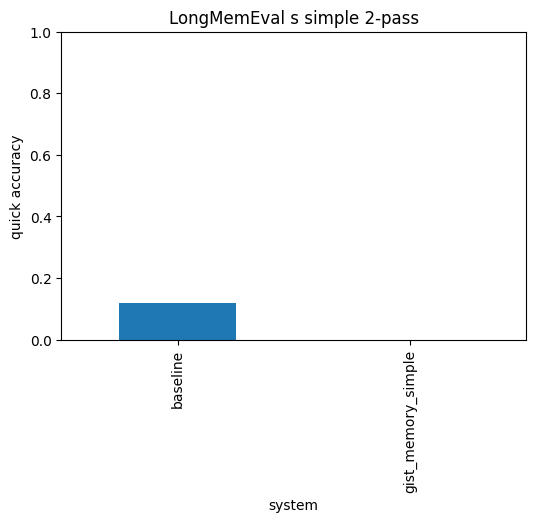

In [49]:
overall.plot(kind="bar", x="system", y="correct", legend=False, figsize=(6,4))
plt.ylim(0, 1)
plt.ylabel("quick accuracy")
plt.title(f'LongMemEval {SET["run_set"]} simple 2-pass')
plt.show()

In [50]:
cmp = base_df.merge(
    mem_df[["question_id", "pred", "correct"]],
    on="question_id",
    suffixes=("_base", "_mem")
)

wins = cmp[(cmp["correct_base"] == 0) & (cmp["correct_mem"] == 1)]
losses = cmp[(cmp["correct_base"] == 1) & (cmp["correct_mem"] == 0)]

print("memory wins:", len(wins))
print("memory losses:", len(losses))
wins[["question_id", "question_type", "question", "gold", "pred_base", "pred_mem"]].head(10)

memory wins: 0
memory losses: 30


,question_id,question_type,question,gold,pred_base,pred_mem


In [51]:
def save_jsonl(df, path):
    with open(path, "w") as f:
        for _, r in df.iterrows():
            f.write(json.dumps({
                "question_id": r["question_id"],
                "hypothesis": r["pred"]
            }) + "\n")

run_set = SET["run_set"]
save_dir = SET["save_dir"]
os.makedirs(save_dir, exist_ok=True)

save_jsonl(base_df, f"{save_dir}/{run_set}_baseline.jsonl")
save_jsonl(mem_df, f"{save_dir}/{run_set}_gist_memory_simple.jsonl")

base_df.to_csv(f"{save_dir}/{run_set}_baseline.csv", index=False)
mem_df.to_csv(f"{save_dir}/{run_set}_gist_memory_simple.csv", index=False)
overall.to_csv(f"{save_dir}/{run_set}_overall.csv", index=False)
by_type.to_csv(f"{save_dir}/{run_set}_by_type.csv", index=False)

print("saved to", save_dir)

saved to runs_simple


In [52]:
def judge_match(gold, pred):
    prompt = f"""
You are grading whether a predicted answer matches a gold answer.

Rules:
- Mark MATCH if the predicted answer is semantically equivalent to the gold answer.
- Allow paraphrases, abbreviations, and minor formatting differences.
- Mark MATCH if the prediction contains the gold answer clearly and correctly.
- Mark NO_MATCH if the prediction is wrong, contradicts the gold answer, is unrelated, or says unknown when the gold answer is known.
- Respond only as JSON:
{{"match": 0 or 1, "reason": "short reason"}}

Gold answer: {gold}
Predicted answer: {pred}
""".strip()

    out = llm(prompt, max_new_tokens=80)

    m = re.search(r"\{[\s\S]*\}", out)
    if not m:
        return 0, out.strip()

    try:
        d = json.loads(m.group(0))
        return int(d.get("match", 0)), str(d.get("reason", "")).strip()
    except:
        return 0, out.strip()

def llm_grade_df(df, name="system"):
    rows = []
    for i, r in df.iterrows():
        match, reason = judge_match(r["gold"], r["pred"])
        rows.append({
            "system": name,
            "question_id": r["question_id"],
            "question_type": r["question_type"],
            "question": r["question"],
            "gold": r["gold"],
            "pred": r["pred"],
            "llm_correct": match,
            "llm_reason": reason
        })
        if (i + 1) % 5 == 0 or i + 1 == len(df):
            print(i + 1, "/", len(df))
    return pd.DataFrame(rows)

base_llm_df = llm_grade_df(base_df, "baseline")
mem_llm_df = llm_grade_df(mem_df, "gist_memory")

print("BASELINE LLM SCORE")
print(base_llm_df["llm_correct"].mean())

print("\nGIST MEMORY LLM SCORE")
print(mem_llm_df["llm_correct"].mean())

display(base_llm_df.head())
display(mem_llm_df.head())

5 / 250
10 / 250
15 / 250
20 / 250
25 / 250
30 / 250
35 / 250
40 / 250
45 / 250
50 / 250
55 / 250
60 / 250
65 / 250
70 / 250
75 / 250
80 / 250
85 / 250
90 / 250
95 / 250
100 / 250
105 / 250
110 / 250
115 / 250
120 / 250
125 / 250
130 / 250
135 / 250
140 / 250
145 / 250
150 / 250
155 / 250
160 / 250
165 / 250
170 / 250
175 / 250
180 / 250
185 / 250
190 / 250
195 / 250
200 / 250
205 / 250
210 / 250
215 / 250
220 / 250
225 / 250
230 / 250
235 / 250
240 / 250
245 / 250
250 / 250
5 / 250
10 / 250
15 / 250
20 / 250
25 / 250
30 / 250
35 / 250
40 / 250
45 / 250
50 / 250
55 / 250
60 / 250
65 / 250
70 / 250
75 / 250
80 / 250
85 / 250
90 / 250
95 / 250
100 / 250
105 / 250
110 / 250
115 / 250
120 / 250
125 / 250
130 / 250
135 / 250
140 / 250
145 / 250
150 / 250
155 / 250
160 / 250
165 / 250
170 / 250
175 / 250
180 / 250
185 / 250
190 / 250
195 / 250
200 / 250
205 / 250
210 / 250
215 / 250
220 / 250
225 / 250
230 / 250
235 / 250
240 / 250
245 / 250
250 / 250
BASELINE LLM SCORE
0.16

GIST MEMORY LLM

,system,question_id,question_type,question,gold,pred,llm_correct,llm_reason
0,baseline,0862e8bf_abs,single-session-user,What is the name of my hamster?,You did not mention this information. You ment...,unknown,0,Prediction says 'unknown' while the gold answe...
1,baseline,15745da0_abs,single-session-user,How long have I been collecting vintage films?,You did not mention this information. You ment...,unknown,0,Prediction says 'unknown' while the gold answe...
2,baseline,bc8a6e93_abs,single-session-user,What did I bake for my uncle's birthday party?,You did not mention this information. You ment...,unknown,0,Prediction says 'unknown' while the gold answe...
3,baseline,19b5f2b3_abs,single-session-user,How long was I in Korea for?,You did not mention this information. You ment...,unknown,1,The predicted answer 'unknown' indicates that ...
4,baseline,29f2956b_abs,single-session-user,How much time do I dedicate to practicing viol...,You did not mention this information. You ment...,unknown,1,The predicted answer 'unknown' indicates that ...


,system,question_id,question_type,question,gold,pred,llm_correct,llm_reason
0,gist_memory,0862e8bf_abs,single-session-user,What is the name of my hamster?,You did not mention this information. You ment...,unknown,0,Prediction says 'unknown' while the gold answe...
1,gist_memory,15745da0_abs,single-session-user,How long have I been collecting vintage films?,You did not mention this information. You ment...,unknown,0,Prediction says 'unknown' while the gold answe...
2,gist_memory,bc8a6e93_abs,single-session-user,What did I bake for my uncle's birthday party?,You did not mention this information. You ment...,unknown,0,Prediction says 'unknown' while the gold answe...
3,gist_memory,19b5f2b3_abs,single-session-user,How long was I in Korea for?,You did not mention this information. You ment...,unknown,1,The predicted answer 'unknown' indicates that ...
4,gist_memory,29f2956b_abs,single-session-user,How much time do I dedicate to practicing viol...,You did not mention this information. You ment...,unknown,1,The predicted answer 'unknown' indicates that ...


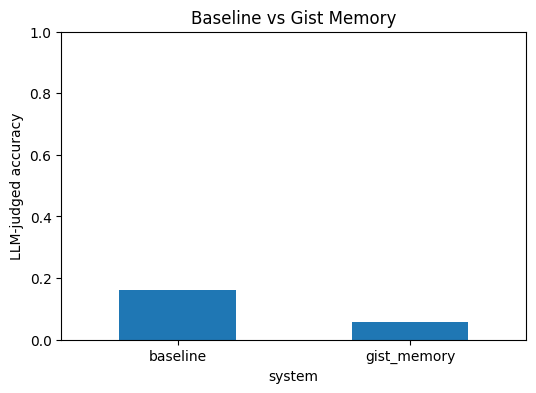

In [53]:
# Graph LLM-judged accuracy

plot_df = pd.DataFrame({
    "system": ["baseline", "gist_memory"],
    "llm_accuracy": [
        base_llm_df["llm_correct"].mean(),
        mem_llm_df["llm_correct"].mean()
    ]
})

ax = plot_df.plot(kind="bar", x="system", y="llm_accuracy", legend=False, figsize=(6,4))
plt.ylim(0, 1)
plt.ylabel("LLM-judged accuracy")
plt.title("Baseline vs Gist Memory")
plt.xticks(rotation=0)
plt.show()

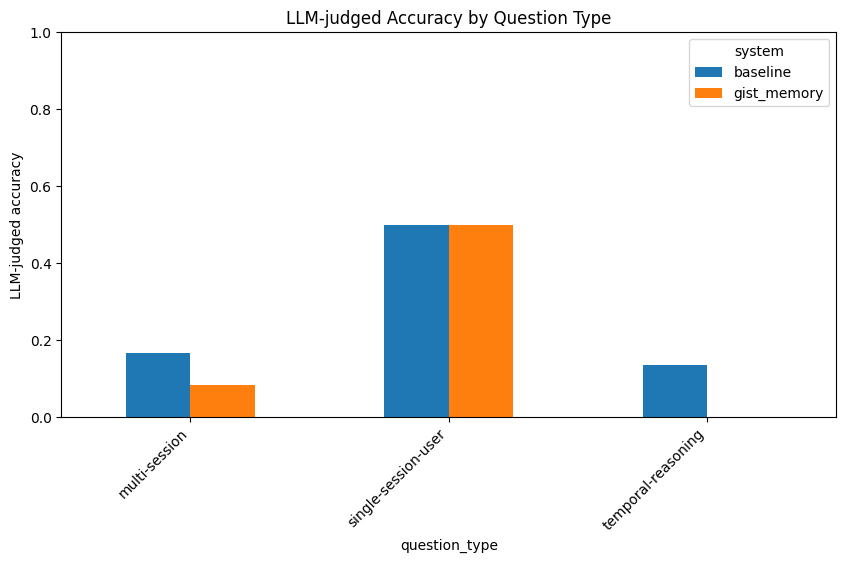

In [54]:
# Graph LLM-judged accuracy by question type

by_type_plot = pd.concat([base_llm_df, mem_llm_df], ignore_index=True)
by_type_plot = by_type_plot.groupby(["system", "question_type"], as_index=False)["llm_correct"].mean()

pivot_df = by_type_plot.pivot(index="question_type", columns="system", values="llm_correct")
pivot_df.plot(kind="bar", figsize=(10,5))
plt.ylim(0, 1)
plt.ylabel("LLM-judged accuracy")
plt.title("LLM-judged Accuracy by Question Type")
plt.xticks(rotation=45, ha="right")
plt.show()